<a href="https://colab.research.google.com/github/daniivelascoo/ifp-programacion-ia/blob/main/Lab_2_3_Diamonds_Pipeline_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💎 Laboratorio 2.3: El Tasador de Diamantes (Pipelines)
**Núcleo Formativo 2 - Ingeniería de Datos Avanzada**

---
### 📜 Contexto del Negocio
Trabajas para una joyería de lujo. Quieren automatizar la tasación de diamantes.
Tienes datos históricos con características técnicas:
*   **Numéricas:** `carat` (quilates), `depth`, `table`, dimensiones (`x`, `y`, `z`).
*   **Categóricas:** `cut` (corte), `color`, `clarity`.

### 🎯 Tu Misión
El reto es que los datos son heterogéneos. No puedes pasar texto ("Premium") a una fórmula matemática. Y no puedes mezclar Quilates (0.2) con Precio (3000) sin escalar.

Debes construir un **Pipeline Profesional** que:
1.  Separe automáticamente columnas numéricas y categóricas.
2.  Aplique **StandardScaler** a los números.
3.  Aplique **OneHotEncoder** al texto.
4.  Entrene una **Regresión Lineal** para predecir el precio.

---

In [1]:
# --- ⚙️ 0. CARGA DE DATOS (NO TOCAR) ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cargamos el dataset desde la librería Seaborn
df = sns.load_dataset('diamonds')

# Muestreo: Trabajaremos con 5.000 diamantes para que vaya rápido
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

print("✅ Datos cargados.")
display(df.head())
print(df.info())

✅ Datos cargados.


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
1,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
2,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
3,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
4,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    5000 non-null   float64 
 1   cut      5000 non-null   category
 2   color    5000 non-null   category
 3   clarity  5000 non-null   category
 4   depth    5000 non-null   float64 
 5   table    5000 non-null   float64 
 6   price    5000 non-null   int64   
 7   x        5000 non-null   float64 
 8   y        5000 non-null   float64 
 9   z        5000 non-null   float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 289.1 KB
None


---
## ✂️ FASE 1: Metodología (Split)

Antes de tocar nada, separamos los datos.
*   **X:** Todo menos `price`.
*   **y:** La columna `price`.
*   **Split:** 80% Train, 20% Test (`random_state=42`).


In [3]:
from sklearn.model_selection import train_test_split

# 1. Separar X e y
X = df.drop('price', axis=1) # Quita el precio
y = df['price']

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Diamantes para entrenar: {X_train.shape[0]}")
print(f"Diamantes para testear:  {X_test.shape[0]}")

Diamantes para entrenar: 4000
Diamantes para testear:  1000


---
## ⚙️ FASE 2: El Preprocesador (ColumnTransformer)

Aquí está la magia. Vamos a crear un objeto que trata diferente a cada columna.

1.  Definimos las listas de columnas.
2.  Creamos el `ColumnTransformer` aplicando:
    *   `StandardScaler` a las numéricas.
    *   `OneHotEncoder` a las categóricas.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Listas de columnas (Ya te las damos hechas)
# Fíjate que en X ya no está 'price'
num_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
cat_features = ['cut', 'color', 'clarity']

# 2. Crear el Transformador de Columnas
# Sintaxis: ('nombre_paso', Transformador(), lista_columnas)

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),  # Escalar números
        ('cat', OneHotEncoder(), cat_features)   # Codificar texto
    ]
)

print("✅ Preprocesador configurado.")

✅ Preprocesador configurado.


### 📝 REFLEXIÓN DE INGENIERÍA (Obligatorio)
*Haz doble clic aquí para editar.*

**Pregunta:** ¿Por qué usamos `StandardScaler` en la columna 'carat' (quilates)? ¿Qué pasaría si la mezclamos con 'depth' sin escalar?

**Respuesta:**

---
## 🤖 FASE 3: El Pipeline Completo

Unimos el preprocesador con el modelo final (`LinearRegression`).

1.  Crea el `Pipeline`.
2.  Entrénalo (`.fit`) con los datos de **TRAIN**.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# 1. Crear Pipeline
pipeline_tasador = Pipeline(steps=[
    ('preproceso', preprocesador), # Lo que creamos en Fase 2
    ('modelo', LinearRegression())          # El cerebro (Regresión Lineal)
])

# 2. Entrenar
print("🧠 Entrenando al tasador...")
pipeline_tasador.fit(X_train, y_train) # Usa X_train, y_train

print("¡Modelo listo!")

🧠 Entrenando al tasador...
¡Modelo listo!


---
## 📝 FASE 4: Evaluación (R2 Score)

Vamos a ver qué tal funciona. En regresión usamos el **R2 Score** (Coeficiente de Determinación).
*   1.0 = Perfecto.
*   0.0 = Malo (Predice la media).

**Misión:**
1.  Calcula el R2 usando `.score(X_test, y_test)` directamente sobre el pipeline.
2.  Imprime el resultado.

In [7]:
# El método .score() en regresión devuelve el R2 automáticamente
nota = pipeline_tasador.score(X_test, y_test)

print(f"R2 Score del modelo: {nota:.4f}")

R2 Score del modelo: 0.9140


---
## ⭐ PARTE EXTRA: Gráfico de Predicción (Bonus)
**Objetivo:** Para el 10, visualiza qué tal lo ha hecho el modelo.

1.  Genera las predicciones (`y_pred`) usando el pipeline sobre `X_test`.
2.  Crea un gráfico de dispersión (`sns.scatterplot`).
    *   Eje X: `y_test` (Realidad).
    *   Eje Y: `y_pred` (Predicción).
    *   *Pista:* Si el modelo fuera perfecto, todos los puntos formarían una línea diagonal.

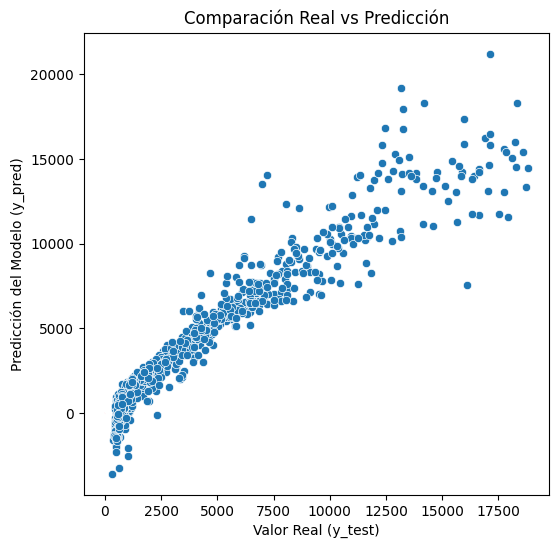

In [9]:
# TU CÓDIGO AQUÍ

y_pred = pipeline_tasador.predict(X_test)

# Scatter plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Valor Real (y_test)")
plt.ylabel("Predicción del Modelo (y_pred)")
plt.title("Comparación Real vs Predicción")

# Línea diagonal ideal
plt.plot([0,1],[0,1], color="red", linestyle="--")

plt.show()

---
## 🏁 VALIDACIÓN FINAL
Ejecuta la celda de abajo.

In [10]:
# --- 🤖 CÓDIGO DE VALIDACIÓN (NO MODIFICAR) ---
def validar_diamonds():
    print("🚀 AUDITANDO INGENIERÍA DE DIAMANTES...\n")
    puntos = 0
    errores = []

    v_pipe = globals().get('pipeline_tasador')
    v_pre = globals().get('preprocesador')
    v_X_test = globals().get('X_test')

    # 1. VALIDAR PREPROCESADOR
    if v_pre is not None:
        if hasattr(v_pre, 'transformers'):
            # Buscar StandardScaler y OneHotEncoder en los transformers
            t_str = str(v_pre.transformers)
            if 'StandardScaler' in t_str and 'OneHotEncoder' in t_str:
                print("✅ [FASE 2] ColumnTransformer: CORRECTO.")
                puntos += 2.5
            else:
                errores.append("❌ Faltan transformadores adecuados (Scaler/Encoder).")
        else:
            errores.append("❌ 'preprocesador' no es un ColumnTransformer.")
    else:
        errores.append("❌ No encuentro la variable 'preprocesador'.")

    # 2. VALIDAR PIPELINE
    if v_pipe is not None:
        if hasattr(v_pipe, 'named_steps'):
            if 'modelo' in v_pipe.named_steps:
                print("✅ [FASE 3] Arquitectura Pipeline: CORRECTA.")
                puntos += 2.5
            else:
                errores.append("❌ El pipeline no tiene un paso llamado 'modelo'.")
        else:
            errores.append("❌ 'pipeline_tasador' no es un Pipeline.")
    else:
        errores.append("❌ No encuentro el pipeline.")

    # 3. VALIDAR RENDIMIENTO
    if v_pipe is not None and v_X_test is not None:
        try:
            score = v_pipe.score(v_X_test, globals()['y_test'])
            if score > 0.85:
                print(f"✅ [FASE 4] Rendimiento: EXCELENTE (R2: {score:.4f}).")
                puntos += 2.5
            elif score > 0.60:
                print(f"⚠️ [FASE 4] Rendimiento Aceptable (R2: {score:.4f}).")
                puntos += 1.5
            else:
                errores.append(f"❌ El modelo falla mucho (R2: {score:.4f}). Revisa el preprocesamiento.")
        except:
            errores.append("❌ Error al evaluar el modelo. ¿Está entrenado?")

    # 4. BONUS TRACK
    historial = "\n".join(globals().get('_ih', []))
    if 'scatterplot' in historial and 'y_pred' in historial:
        print("🌟 [BONUS] Gráfico de Realidad vs Predicción detectado.")
        puntos += 2.5
    else:
        print("ℹ️ [BONUS] No has hecho el gráfico final.")

    # REPORTE
    print("\n" + "="*50)
    if puntos >= 7.5:
        import hashlib
        code = hashlib.md5(str(puntos).encode()).hexdigest()[:8].upper()
        print(f"🎉 ¡JOYERO EXPERTO! Pipeline completado.")
        print(f"🔐 CÓDIGO DE VALIDACIÓN: DIAMOND-{code}")
        print(">> Sube el notebook a la plataforma.")
    else:
        print("⚠️ REVISA LOS ERRORES:")
        for e in errores: print(f"   - {e}")
    print("="*50)

validar_diamonds()

🚀 AUDITANDO INGENIERÍA DE DIAMANTES...

✅ [FASE 2] ColumnTransformer: CORRECTO.
✅ [FASE 3] Arquitectura Pipeline: CORRECTA.
✅ [FASE 4] Rendimiento: EXCELENTE (R2: 0.9140).
🌟 [BONUS] Gráfico de Realidad vs Predicción detectado.

🎉 ¡JOYERO EXPERTO! Pipeline completado.
🔐 CÓDIGO DE VALIDACIÓN: DIAMOND-43A1437F
>> Sube el notebook a la plataforma.
